In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver
from sionna.rt import *
import mitsuba as mi
import sys

np.random.seed(100)

np.set_printoptions(suppress=True)
np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(threshold=np.inf, linewidth=np.nan)

2026-05-19 02:55:51.667164: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 02:55:52.138876: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-19 02:55:55.653834: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [7]:
# Locations of the Transmitter and receiver
# Blender --> Sionna
# X       -->  X
# Y       --> -Z
# Z       -->  Y
rx_locations = np.array([21, 4, -1]) 
tx_locations = np.array([21, -7, -1])

obj_pos = np.array([200, 300, -0.9]) # Initial position of the object in static environment
obj_pos_dynamic = np.array([17, -1.8, -0.9]) # Initial position of the object in static environment
obj_dim = np.array([0.25, 0.5, 1.8]) # Object dimension

K = 100 # No. of times the simulation will run
Te = 0.08 # Seconds between successive simulation runs
v_0 = np.array([0, 0.17, 0]) # Speed of the object in m/s

# Carrier frequency
scene.frequency = 3.6192e9

parameters = np.zeros([K, 4, 25]) # Save the channel parameters in a numpy array for being used by ISAC simulator
positions = np.zeros([K, 2]) # Save the position of the object
obj_params = np.zeros([K, 3]) # Save the true AoA, ToF and visibility of the object to the transmitter

# Load the Sionna scene 
scene = load_scene("/home/bkumar2/Documents/Research/ISAC-twin/Simulation_framework/Datasets/Outdoor_scenario/Blender/Outdoor.xml", merge_shapes=False)

# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="VH")

tx = Transmitter(name="tx",
                 position=tx_locations,
                 display_radius=2)

scene.add(tx)

rx = Receiver(name="rx",
              position=rx_locations,
              display_radius=2)

scene.add(rx)

# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

scene.get('elm__4').position = mi.Point3f(obj_pos)

for k in range(0, 34):
    
    if k == 30:
        obj_pos = obj_pos_dynamic
    
    # Compute propagation paths
    paths = p_solver(scene=scene,
                     max_depth=2,
                     #max_num_paths_per_src=3,
                     los=True,
                     specular_reflection=True,
                     diffuse_reflection=True,
                     refraction=True,
                     synthetic_array=False,
                     seed=41)
    
    poi = np.array(paths.vertices[:, 0, 0, 0, :, :])
    L = np.shape(poi)[2]
    
    for l in range(0, L):
        
        if (paths.phi_r[0,0,0,0,l] < 0): # We are ignoring all the paths that are received from behind of the BS array.
            
            for order in range(0, 2):        
                if((obj_pos[0]-obj_dim[0]/2-0.05 <= poi[order,0,l,0] and poi[order,0,l,0] <= obj_pos[0]+obj_dim[0]/2+0.05) and \
                   (obj_pos[1]-obj_dim[1]/2-0.05 <= poi[order,0,l,1] and poi[order,0,l,1] <= obj_pos[1]+obj_dim[1]/2+0.05) and \
                   (obj_pos[2]-obj_dim[2]/2-0.05 <= poi[order,0,l,2] and poi[order,0,l,2] <= obj_pos[2]+obj_dim[2]/2+0.05)):

                    if (order == 0) and (poi[1,0,l,0] == 0 and poi[1,0,l,1] == 0 and poi[1,0,l,2] == 0):
                        print("{}th path of {}th iteration has first order reflection from the moving object".format(l, k))
                        obj_params[k, 0] = np.array(paths.phi_r[0,0,0,0,l]*180/np.pi) # Save the AoA from the object of interest
                        obj_params[k, 1] = np.array(paths._tau[0,0,0,0,l]*1e9) # Save the delay from the object of interest
                        obj_params[k, 2] = 1 # Save the visibility of the object
        #                 sys.exit()

                    else:
                        print("{}th path of {}th iteration has higher order reflection from the moving object".format(l, k))
                        obj_params[k, 0] = np.array(paths.phi_r[0,0,0,0,l]*180/np.pi) # Save the AoA from the object of interest
                        obj_params[k, 1] = np.array(paths._tau[0,0,0,0,l]*1e9) # Save the delay from the object of interest
                        obj_params[k, 2] = 1 # Save the visibility of the object
    
    parameters[k, 0, 0:np.min(np.array([L, 25]))] = np.array(paths.phi_r[0,0,0,0,0:np.min(np.array([L, 25]))])
    parameters[k, 1, 0:np.min(np.array([L, 25]))] = np.array(paths._doppler[0,0,0,0,0:np.min(np.array([L, 25]))])
    parameters[k, 2, 0:np.min(np.array([L, 25]))] = np.array(paths._tau[0,0,0,0,0:np.min(np.array([L, 25]))])
    
    a_v = np.array(paths._a_real[0,0,0,0,0:np.min(np.array([L, 25]))]) + 1j*np.array(paths._a_imag[0,0,0,0,0:np.min(np.array([L, 25]))])
    a_h = np.array(paths._a_real[0,1,0,0,0:np.min(np.array([L, 25]))]) + 1j*np.array(paths._a_imag[0,1,0,0,0:np.min(np.array([L, 25]))])
    parameters[k, 3, 0:np.min(np.array([L, 25]))] = np.abs(a_v)**2 + np.abs(a_h)**2
    
    print("The location of object in gNB frame of reference is [{}, {}]".format(rx_locations[0]-obj_pos[0], rx_locations[1]-obj_pos[1]))
    print("{}th iteration is done".format(k))
    
    positions[k, 0] = rx_locations[0]-obj_pos[0]
    positions[k, 1] = rx_locations[1]-obj_pos[1]
    
    obj_pos = obj_pos + Te*v_0
    scene.get('elm__4').position = mi.Point3f(obj_pos)
    
    
np.save('/home/bkumar2/Documents/Research/ISAC-twin/Simulation_framework/Datasets/Outdoor_scenario/Trajectory_3/ISAC_ray_tracing_chan.npy', parameters)
np.save('/home/bkumar2/Documents/Research/ISAC-twin/Simulation_framework/Datasets/Outdoor_scenario/Trajectory_3/ISAC_locations.npy', positions)
np.save('/home/bkumar2/Documents/Research/ISAC-twin/Simulation_framework/Datasets/Outdoor_scenario/Trajectory_3/obj_params.npy', obj_params)

The location of object in gNB frame of reference is [-179.0, -296.0]
0th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.0136]
1th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.0272]
2th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.0408]
3th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.0544]
4th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.068]
5th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.0816]
6th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.0952]
7th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.1088]
8th iteration is done
The location of object in gNB frame of reference is [-179.0, -296.12239999999997]
9th iteration is done
The location of object in gNB frame of reference is [-

In [7]:
paths = p_solver(scene=scene,
                 max_depth=4,
                 #max_num_paths_per_src=3,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=True,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

In [3]:
a = np.load('ISAC_chan.npy')
np.shape(a)

(100, 4, 25)

In [6]:
scene.objects

{'elm__3': <sionna.rt.scene_object.SceneObject at 0x7ccaa481d2e0>,
 'elm__5': <sionna.rt.scene_object.SceneObject at 0x7ccaa4864830>}

In [6]:
print(paths.phi_r*180/np.pi)
print("--------------------")
# print(paths.theta_r*180/np.pi)
# print("--------------------")
# print(np.shape(paths.interactions))
# print("--------------------")
print(paths.interactions[:, :, 0, :, :, :])
# print("--------------------")
print(paths.vertices[:, :, 0, :, :, :])
# print("--------------------")
# # print(paths.objects[:, :, 0, :, :, :])
# print(np.shape(paths.vertices[:, :, 0, :, :, :]))
# print(np.shape(paths.phi_r))
print("--------------------")
print(paths.a)
print("----------")
# print(paths._a_real)
# print("----------")
# print(paths._a_imag)
# print(np.shape(paths.a))
# print(np.shape(paths._a_imag))
# print(np.shape(paths._doppler))
print(paths._tau*1e9)
print(np.shape(paths.vertices[:, :, 0, :, :, :]))

(1, 2, 1, 1, 54)
--------------------
[[[[[0, 1, 4, .. 48 skipped .., 4, 4, 4]]]],
 [[[[0, 0, 1, .. 48 skipped .., 1, 1, 1]]]],
 [[[[0, 0, 4, .. 48 skipped .., 1, 1, 1]]]],
 [[[[0, 0, 0, .. 48 skipped .., 4, 4, 4]]]]]
[[[[[[0, 0, 0],
     [21, -1.50054, -0.328168],
     [21, -3.19716, -0.328168],
     .. 48 skipped ..,
     [21.1819, 73.3451, -8.03486],
     [-68.1337, -2.54253, -12.7623],
     [34.715, -6.08157, -5.3335]]]]],
 [[[[[0, 0, 0],
     [0, 0, 0],
     [21, -1.49979, -0.0281702],
     .. 48 skipped ..,
     [21.2394, 98.7674, -10.2614],
     [-99.9391, -0.951978, -16.96],
     [76.7786, -3.26483, -18.6241]]]]],
 [[[[[0, 0, 0],
     [0, 0, 0],
     [21, 0.197558, -0.328168],
     .. 48 skipped ..,
     [21.2519, 104.268, -9.77982],
     [-99.9643, -0.950745, -16.9567],
     [76.6081, -3.24261, -18.6788]]]]],
 [[[[[0, 0, 0],
     [0, 0, 0],
     [0, 0, 0],
     .. 48 skipped ..,
     [21.1742, 73.345, -7.07213],
     [-68.1015, 0.353301, -12.7536],
     [34.7911, 2.20377, -5.3

In [9]:
print(paths.phi_r[0,0,0,:,:]*180/np.pi)

[[0, 180, -180, .. 21 skipped .., 180, 91.3821, -102.559]]


In [8]:
# Save the channel parameters in a numpy array for being used by ISAC simulator

parameters = np.zeros([4, len(paths.phi_r[0,0,0,0,:])])
parameters[0, :] = np.array(paths.phi_r[0,0,0,0,:])
parameters[1, :] = np.array(paths._doppler[0,0,0,0,:])
parameters[2, :] = np.array(paths._tau[0,0,0,0,:]) - paths._tau[0,0,0,0,0]

a_v = np.array(paths._a_real[0,0,0,0,:]) + 1j*np.array(paths._a_imag[0,0,0,0,:])
a_h = np.array(paths._a_real[0,1,0,0,:]) + 1j*np.array(paths._a_imag[0,1,0,0,:])
parameters[3, :] = np.abs(a_v)**2 + np.abs(a_h)**2

np.save('ISAC_chan.npy', parameters)

In [14]:
dir(paths)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_a_imag',
 '_a_real',
 '_apply_synthetic_array',
 '_build_empty_paths',
 '_build_from_buffer',
 '_build_paths_components',
 '_doppler',
 '_eff_rx_array_size',
 '_eff_tx_array_size',
 '_finalize_doppler_shift_compute',
 '_frequency',
 '_fuse_pattern_array_dims',
 '_interactions',
 '_max_num_paths',
 '_num_rx',
 '_num_tx',
 '_path_ind',
 '_paths_buffer',
 '_paths_components_built',
 '_phi_r',
 '_phi_t',
 '_primitives',
 '_reverse_direction',
 '_rx_ant_ind',
 '_rx_array',
 '_rx_ind',
 '_rx_velocities',
 '_shapes',
 '_src_positions',
 '_synthetic_array',
 '_tau',
 '_tgt_positions',
 '_theta_r',
 '_theta_t',


In [5]:
for i, obj in enumerate(scene.objects.values()):
    print(f"{obj.name} and {obj.radio_material.name}")

elm__3 and concrete
elm__5 and metal
elm__6 and concrete
elm__7 and metal
elm__8 and concrete
elm__9 and metal
elm__10 and metal
elm__11 and metal
elm__12 and metal
elm__14 and glass
elm__15 and metal
elm__16 and metal
elm__18 and plasterboard
elm__19 and glass


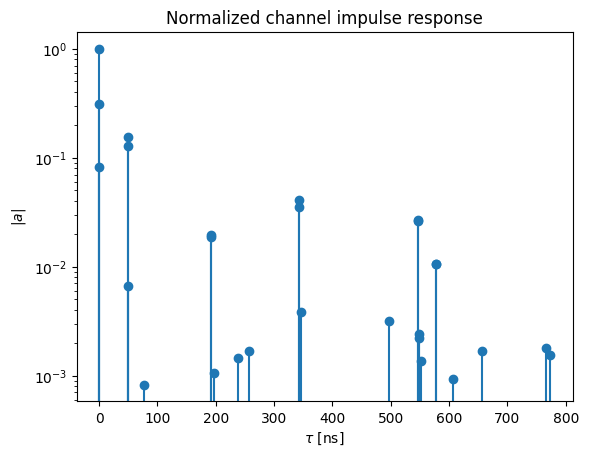

In [10]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")
t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)
a_abs = a_abs/a_max

# And plot the CIR
plt.figure()
plt.title("Normalized channel impulse response")
plt.stem(t, a_abs)
plt.semilogy()
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

In [8]:
scene.preview(paths=paths)

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …